**Projet Trafic Paris**


**Contexte** : on va analyser letrafic routier de la Ville de Paris à partir des boucles électromagnétiques (comptages horaires).

**Mes 3 axes** : Bd_Barbes, Av_Pdt_Kennedy, Av_Grande_Armee *

**Période** : du 1er mars au 31 août 2026

**Source** : les données de comptages routiers permanents de la Ville de Paris (opendata.paris.fr)

## 2. Téléchargement des données
J'ai téléchargé les données avec `download_data.py` (la liste `ROUTES` modifiée , j'ai ajouté mes trois axes listés en hauts). Ensuite le fichier `data/raw/comptages.csv` n'est pas versionné car il est exclu par `.gitignore`.

In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

Mettons l'address du fichier dans une variable pour ne pas avoir a le réecrir partout.

In [2]:
CHEMIN = "data/raw/comptages.csv"
print(f"Taille du fichier : {os.path.getsize(CHEMIN) / 1e6:.1f} Mo")

Taille du fichier : 12.6 Mo


## 2. Chargement par chunks
Le fichier fait ~13 Mo pour mes 3 axes, mais la base complète fait près de 30 millions de lignes. Le chargement par morceaux permet de filtrer ou d'agréger pendant la lecture, sans jamais tout avoir en mémoire. 

In [3]:
TYPES = { "iu_ac": "string", "iu_nd_amont": "string", "iu_nd_aval": "string",
    "libelle": "category", "etat_trafic": "category", "etat_barre": "category",}
morceaux = []
for i, chunk in enumerate(pd.read_csv(CHEMIN, sep=";", encoding="utf-8-sig",
                                      dtype=TYPES, chunksize=50_000)):
    morceaux.append(chunk)
print(f"{i + 1} chunks lus")

df = pd.concat(morceaux, ignore_index=True)
df.shape

2 chunks lus


(95960, 11)

Le chargement donne 95 960 lignes et 11 colonnes, ce qui correspond exactement à la somme annoncée dans liste_des_axes.csv pour mes 3 axes (52 368 + 26 184 + 17 408).

In [4]:
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
df["libelle"].value_counts()

Mémoire : 14.5 Mo


libelle
Bd_Barbes          52368
Av_Pdt_Kennedy     26184
Av_Grande_Armee    17408
Name: count, dtype: int64

## 3. Exploration : dimensions, types, valeurs manquantes

In [5]:
print("Dimensions :", df.shape)
df.dtypes

Dimensions : (95960, 11)


iu_ac                 string
libelle             category
t_1h                     str
q                    float64
k                    float64
etat_trafic         category
iu_nd_amont           string
libelle_nd_amont         str
iu_nd_aval            string
libelle_nd_aval          str
etat_barre          category
dtype: object

In [6]:
manquantes = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
manquantes
df[["q", "k"]].describe()
df["etat_trafic"].value_counts(dropna=False)
df["etat_barre"].value_counts(dropna=False)

etat_barre
Ouvert      92658
Invalide     3202
Barré         100
Name: count, dtype: int64

## 4. Graphiques

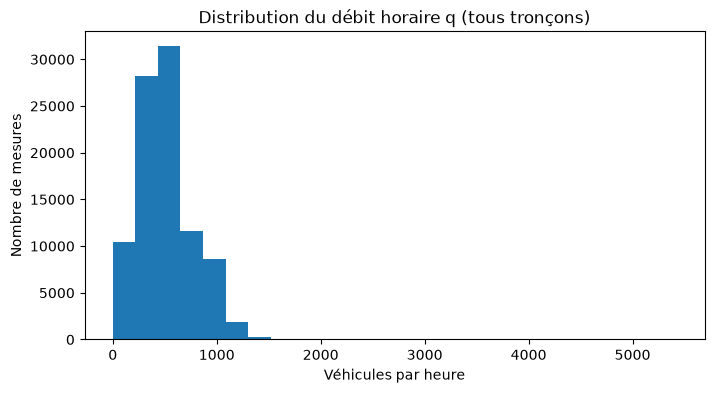

In [7]:
df["q"].plot.hist(bins=25, figsize=(8, 4))
plt.title("Distribution du débit horaire q (tous tronçons)")
plt.xlabel("Véhicules par heure")
plt.ylabel("Nombre de mesures")
plt.show() 

**Lecture** : L'histogramme montre trois choses: Tout d'abord la distribution est assymétrique, les mesures sont concentrées entre 0 et 1200 vehicules par heure et on a un pic net vers 400-500 vehicules par heure . Ensuite , on a une petite deuxième bosse autour de 700-900, elle pourrait peut etre venir des heures de point. En fin , on a un axe horizontal qui monte jusqu'à plus de 5 000 voitures par heure , alors que l'on ne voit rien apres environ 1400, ce qui veut dire qu'on a quelques valeurs extrêmes, trop rares pour être visibles. Elles sont suspectes car un tronçon d'un boulevard ne laisse pas passer 5 000 véhicules par heure.

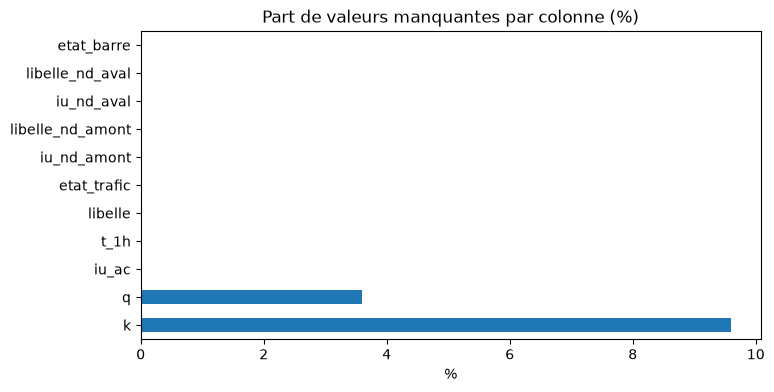

In [8]:
manquantes.plot.barh(figsize=(8, 4))
plt.title("Part de valeurs manquantes par colonne (%)")
plt.xlabel("%")
plt.show()

**Lecture**: On a que  k (taux d'occupation) est la colonne la plus vide, avec environ 9,6 % de valeurs manquantes.
En suite q (débit) est vide à environ 3,6 %.
Toutes les autres colonnes sont à 0 % ou presque (identifiants, date, libellés, etat_barre).

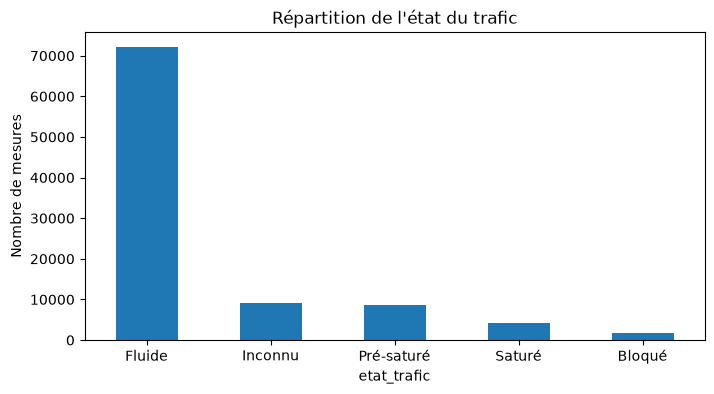

In [9]:
df["etat_trafic"].value_counts(dropna=False).plot.bar(figsize=(8, 4))
plt.title("Répartition de l'état du trafic")
plt.ylabel("Nombre de mesures")
plt.xticks(rotation=0)
plt.show()

**Lecture**: Le graphe montre que fluide domine largement : environ 72 000 mesures sur 95 960, soit près de 75 %.
Inconnu arrive en deuxième, avec environ 9 000 mesures (~9,5 %). Ce taux d'environ 9,5 % est très proche de la part de k manquant (~9,6 %). L'état du trafic est sans doute calculé à partir du taux d'occupation, donc quand k est absent, l'état devient Inconnu. C'est plus que Pré-saturé (~8 500), Saturé (~4 000) et Bloqué (~1 700).

In [10]:
#On peut verifier l'hypothese que les valeurs manquantes de k sont liees a l'etat du trafic
print(pd.crosstab(df["etat_trafic"], df["k"].isna())) 

#on a que presque tous les Inconnu correspondent à k manquant (colonne True), l'hypothèse est confirmée.

k            False  True 
etat_trafic              
Bloqué        1847      0
Fluide       72212      0
Inconnu          0   9169
Pré-saturé    8635      0
Saturé        4097      0


## 5. Bilan et pistes pour le nettoyage (M2)

**Ce que l'exploration m'apprend**
- Le chargement donne **95 960 lignes et 11 colonnes**, ce qui correspond à la somme annoncée dans `liste_des_axes.csv` pour mes 3 axes.
- En suite seules deux colonnes ont des valeurs manquantes : `k` (~9,6 %) et `q` (~3,6 %).
`etat_trafic = Inconnu` correspond **exactement** aux lignes où `k` est manquant : les 9 169 lignes `Inconnu` ont toutes `k` absent,  `Inconnu` est donc une valeur manquante déguisée en texte (~9,55 % des lignes), que je traiterai comme telle à M2.

**Ce que je ferai à l'étape M2**
1. **Dates** : convertir `t_1h` en vrai format date, avec le bon fuseau horaire (vérifier le décalage UTC et le passage heure d'été / heure d'hiver).
2. **Doublons** : chercher les lignes répétées (même tronçon, même heure) et mesurer leur nombre avant de les supprimer.
3. **Colonnes inutiles** : examiner les colonnes de carrefours (`iu_nd_*`, `libelle_nd_*`) et ne supprimer que celles dont je peux justifier l'inutilité.
4. **Valeurs manquantes** : décider pour `q` et `k` entre suppression, interpolation ou conservation des `NaN`, selon qu'elles manquent ensemble ou séparément et selon leur répartition par axe.
5. **`Inconnu` et `etat_barre`** : traiter `Inconnu` comme une valeur manquante, et regarder si les tronçons `Barré` ou `Invalide` expliquent les débits à 0 ou absents.